In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [4]:
# Read data
df = pd.read_csv('analysis_data/akulaku_superset_presto_hanmm_ozy.prazuganda_1768968281.csv')
df

,业务类型,会话ID,工单ID,会话开始时间,会话结束时间,客服输入内容,AI总结内容,客服描述内容,AI描述内容,描述内筒是否相同,客服描述-工单问题类型,AI-工单问题类型,工单类型是否相同,AI-总结时间,工单提报时间,处理人
0,AFI,2-21327084-3-1_1768910054,22870730,2026-01-20 18:54:14,2026-01-20 19:11:47,"{""attachFiles"":[{""fileName"":""image_1.jpg"",""fil...","{""success"":true,""data"":{""ticket_type"":""Akulaku...",QUE // Cust kendala penggunaan limit kredit di...,1. Nomor Telepon Pengguna\n 08123456789\n\n2...,否,Akulaku Paylater (Internal) (NEW)/Limit/Tidak ...,Akulaku Paylater (Internal) (NEW)/Limit/Tidak ...,是,2026-01-20 19:13:10,2026-01-20 19:13:26,3-1-3580653597354691585
1,AFI,2-136849925-3-1_1768888051,22868514,2026-01-20 12:47:31,2026-01-20 12:58:55,"{""attachFiles"":[{""fileName"":""image_1.jpg"",""fil...","{""success"":true,""data"":{""ticket_type"":""Akulaku...",Cust infokan tidak bisa menggunakan limit payl...,1. Nomor Telepon Pengguna\n 088299776949\n\n...,否,Akulaku Paylater (Internal) (NEW)/Limit/Tidak ...,Akulaku Paylater (Internal) (NEW)/Limit/Tidak ...,是,2026-01-20 13:49:37,2026-01-20 13:50:27,3-1-3580647394885045251
2,AFI,2-2017932368-3-1_1768886086,22869350,2026-01-20 12:14:46,2026-01-20 12:33:26,"{""attachFiles"":[{""fileName"":""image_1.jpg"",""fil...","{""success"":true,""data"":{""ticket_type"":""Akulaku...",Kendala cust: cust info limit paylater tidak b...,1. Nomor Telepon Pengguna\n 0896041041676\n\...,否,Akulaku Paylater (Internal) (NEW)/Limit/Tidak ...,Akulaku Paylater (Internal) (NEW)/Limit/Tidak ...,是,2026-01-20 15:35:13,2026-01-20 15:36:39,3-1-3559
3,AFI,2-2026551826-3-1_1768910991,22870844,2026-01-20 19:09:51,2026-01-20 19:30:33,"{""attachFiles"":[{""fileName"":""image_1.jpg"",""fil...","{""success"":true,""data"":{""ticket_type"":""Akulaku...",1. Nomor Telepon Pengguna\n 0812345678910\n\...,1. Nomor Telepon Pengguna\n 0812345678910\n\...,是,Akulaku Paylater (Internal) (NEW)/Limit/Tidak ...,Akulaku Paylater (Internal) (NEW)/Limit/Tidak ...,是,2026-01-20 19:31:07,2026-01-20 19:31:29,3-1-3714
4,AFI,2-2001288705-3-1_1768926851,22872213,2026-01-20 23:34:11,2026-01-20 23:46:25,"{""attachFiles"":[{""fileName"":""image_1.jpg"",""fil...","{""success"":true,""data"":{""ticket_type"":""Akulaku...",1. Nomor Telepon Pengguna\n 08123456789\n\n2...,1. Nomor Telepon Pengguna\n 08123456789\n\n2...,否,Akulaku Paylater (Internal) (NEW)/Limit/Tidak ...,Akulaku Paylater (Internal) (NEW)/Limit/Tidak ...,是,2026-01-20 23:55:45,2026-01-20 23:56:48,3-1-3680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1274,AFI,2-74785281-3-1_1768889092,22869046,2026-01-20 13:04:52,2026-01-20 13:23:00,"{""attachFiles"":[{""fileName"":""image_1.jpg"",""fil...","{""success"":true,""data"":{""ticket_type"":""Akulaku...",#QUE\nCustomer complaint : cust tanyakan ubah ...,1. Nomor Telepon Pengguna\n 08123456789\n\n2...,否,General (NEW)/Akun/Informasi Terkait Akun,Akulaku Paylater (Internal) (NEW)/Akun/Informa...,否,2026-01-20 14:58:40,2026-01-20 14:59:01,3-1-3581997115830504451
1275,AFI,2-66756111-3-1_1768887541,22869538,2026-01-20 12:39:01,2026-01-20 12:54:57,"{""attachFiles"":[{""fileName"":""image_1.jpg"",""fil...","{""success"":true,""data"":{""ticket_type"":""Akulaku...",#QUE\nCustomer complaint : cust tanyakan trans...,1. Nomor Telepon Pengguna\n 08123456789\n\n2...,否,Openpay (Online) (NEW)/Tagihan & Pembayaran/Li...,Akulaku Paylater (Internal) (NEW)/Tagihan & Pe...,否,2026-01-20 15:57:04,2026-01-20 15:57:52,3-1-3581997115830504451
1276,ASI_LOAN,2-2016439414-3-1_1768906826,22870474,2026-01-20 18:00:26,2026-01-20 18:06:44,"{""attachFiles"":[],""complaintType"":2,""conversat...","{""success"":true,""data"":{""ticket_type"":""PDL/Pem...",1. Masalah【1】\n Pengguna menanyakan jam oper...,1. Masalah【1】\n Pengguna menanyakan jam oper...,是,Informasi Umum & Feedback/Spam/Masalah Yang Ti...,PDL/Pembayaran & Tagihan (Pinjaman)/Opsi Pemba...,否,2026-01-20 18:33:33,2026-01-20 18:33:54,3-1-3998
1277,AFI,2-24195434-3-1_1768916627,22871322,2026-01-20 20:43:47,2026-01-20 20:59:39,"{""attachFiles"":[],""complaintType"":2,""conversat...","{""suc

In [5]:
df[df['业务类型'] == 'ASI_LOAN']

,业务类型,会话ID,工单ID,会话开始时间,会话结束时间,客服输入内容,AI总结内容,客服描述内容,AI描述内容,描述内筒是否相同,客服描述-工单问题类型,AI-工单问题类型,工单类型是否相同,AI-总结时间,工单提报时间,处理人
5,ASI_LOAN,2-2055027705-3-1_1768924120,22872176,2026-01-20 22:48:40,2026-01-20 22:59:16,"{""attachFiles"":[],""complaintType"":2,""conversat...","{""success"":true,""data"":{""ticket_type"":""PDL/Pem...",1. Masalah【1】\n Saya sudah melakukan pembaya...,1. Masalah【1】\n Saya sudah melakukan pembaya...,是,PDL/Pembayaran & Tagihan (Pinjaman)/Pembayaran...,PDL/Pembayaran & Tagihan (Pinjaman)/Pembayaran...,是,2026-01-20 23:41:17,2026-01-20 23:41:32,3-1-3986480756121405446
11,ASI_LOAN,2-2049109654-3-1_1768915142,22871159,2026-01-20 20:19:02,2026-01-20 20:39:10,"{""attachFiles"":[{""fileName"":""image_1.jpg"",""fil...","{""success"":true,""data"":{""ticket_type"":""PDL/Pem...",1. Masalah\n Cust info sudah membayar tagih...,1. Nomor Telepon Pengguna\n 089603821013\n\n...,否,PDL/Pembayaran & Tagihan (Pinjaman)/Pembayaran...,PDL/Pembayaran & Tagihan (Pinjaman)/Pembayaran...,是,2026-01-20 20:28:07,2026-01-20 20:28:46,3-1-3986481910192539649
18,ASI_LOAN,2-2056106625-3-1_1768905430,22870225,2026-01-20 17:37:10,2026-01-20 17:49:38,"{""attachFiles"":[],""complaintType"":2,""conversat...","{""success"":true,""data"":{""ticket_type"":""Informa...",1. Masalah【1】\n Saya selalu telat bayar tapi...,1. Masalah【1】\n Saya selalu telat bayar tapi...,是,Informasi Umum & Feedback/Incomplete Details /...,Informasi Umum & Feedback/Incomplete Details /...,是,2026-01-20 17:50:04,2026-01-20 17:50:13,3-1-4005
21,ASI_LOAN,2-2027261154-3-1_1768909785,22870651,2026-01-20 18:49:45,2026-01-20 19:00:07,"{""attachFiles"":[],""complaintType"":2,""conversat...","{""success"":true,""data"":{""ticket_type"":""Informa...",1. Masalah【1】\n Pengguna ingin mengajukan pi...,1. Masalah【1】\n Pengguna ingin mengajukan pi...,是,Informasi Umum & Feedback/Incomplete Details /...,Informasi Umum & Feedback/Incomplete Details /...,是,2026-01-20 19:01:14,2026-01-20 19:01:35,3-1-4005
25,ASI_LOAN,2-139464716-3-1_1768916786,22871295,2026-01-20 20:46:26,2026-01-20 20:52:33,"{""attachFiles"":[],""complaintType"":2,""conversat...","{""success"":true,""data"":{""ticket_type"":""Informa...",1. Masalah【1】\n Pinjaman saya tidak lolos pa...,1. Masalah【1】\n Pinjaman saya tidak lolos pa...,是,Informasi Umum & Feedback/Incomplete Details /...,Informasi Umum & Feedback/Incomplete Details /...,是,2026-01-20 20:55:05,2026-01-20 20:55:32,3-1-3998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1267,ASI_LOAN,2-89442127-3-1_1768911035,22870841,2026-01-20 19:10:35,2026-01-20 19:29:43,"{""attachFiles"":[{""fileName"":""image_1.jpg"",""fil...","{""success"":true,""data"":{""ticket_type"":""PDL/Pen...",1. Masalah【1】\n Saya tidak bisa melakukan pe...,1. Masalah【1】\n Saya tidak bisa melakukan pe...,是,PDL/Pengajuan Pinjaman/Informasi Terkait Prose...,PDL/Pengajuan Pinjaman/Informasi Terkait Prose...,是,2026-01-20 19:30:36,2026-01-20 19:30:49,3-1-4005
1270,ASI_LOAN,2-2054323280-3-1_1768916645,22871830,2026-01-20 20:44:05,2026-01-20 20:57:48,"{""attachFiles"":[],""complaintType"":2,""conversat...","{""success"":true,""data"":{""ticket_type"":""PDL/Col...",1. Masalah【1】\n Saya mengalami kendala telat...,1. Masalah【1】\n Saya mengalami kendala telat...,是,PDL/Collection/Keringanan/Diskon Denda,PDL/Collection/Terkait Restrukturisasi,否,2026-01-20 22:25:26,2026-01-20 22:25:51,3-1-3986480756121405446
1271,ASI_LOAN,2-2056113500-3-1_1768914148,22871418,2026-01-20 20:02:28,2026-01-20 20:27:49,"{""attachFiles"":[],""complaintType"":2,""conversat...","{""success"":true,""data"":{""ticket_type"":""Pengkin...",1. Masalah\n Saya memiliki pinjaman di Akula...,1. Nomor Telepon Pengguna\n 085668759854\n\n...,否,Pengkinian Data/Akun - Perubahan Nomor Telepon...,Pengkinian Data/Akun - Perubahan Nomor Telepon...,否,2026-01-20 21:13:09,2026-01-20 21:13:59,3-1-3986481910192539649
1273,ASI_LOAN,2-2020330973-3-1_1768895565,22869067,2026-01-20 14:52:45,2026-01-20 15:01:07,"{""attachFiles"":[],""complaintType"":2,""conver

In [6]:
df.iloc[:,[7,8]]

,客服描述内容,AI描述内容
0,QUE // Cust kendala penggunaan limit kredit di...,1. Nomor Telepon Pengguna\n 08123456789\n\n2...
1,Cust infokan tidak bisa menggunakan limit payl...,1. Nomor Telepon Pengguna\n 088299776949\n\n...
2,Kendala cust: cust info limit paylater tidak b...,1. Nomor Telepon Pengguna\n 0896041041676\n\...
3,1. Nomor Telepon Pengguna\n 0812345678910\n\...,1. Nomor Telepon Pengguna\n 0812345678910\n\...
4,1. Nomor Telepon Pengguna\n 08123456789\n\n2...,1. Nomor Telepon Pengguna\n 08123456789\n\n2...
...,...,...
1274,#QUE\nCustomer complaint : cust tanyakan ubah ...,1. Nomor Telepon Pengguna\n 08123456789\n\n2...
1275,#QUE\nCustomer complaint : cust tanyakan trans...,1. Nomor Telepon Pengguna\n 08123456789\n\n2...
1276,1. Masalah【1】\n Pengguna menanyakan jam oper...,1. Masalah【1】\n Pengguna menanyakan jam oper...
1277,1. Nomor Telepon Pengguna\n 0812345678910\n\...,1. Nomor Telepon Pengguna\n 0812345678910\n\...


### Modelling

In [7]:
model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-V2"
)

def similarity_pct(text1, text2):
    if text1 is None or text2 is None:
        return np.nan
    text1 = str(text1).strip()
    text2 = str(text2).strip()
    if not text1 or not text2:
        return np.nan
    
    emb = model.encode([text1, text2])
    score = cosine_similarity([emb[0]], [emb[1]])[0][0]
    return round(float(score) * 100, 2)

df['similarity_pct'] = df.apply(
    lambda r: similarity_pct(r['客服描述内容'], r['AI描述内容']),
    axis=1
)

In [9]:
similarity = df.iloc[:,[7,8,16]]
similarity

,客服描述内容,AI描述内容,similarity_pct
0,QUE // Cust kendala penggunaan limit kredit di...,1. Nomor Telepon Pengguna\n 08123456789\n\n2...,57.54
1,Cust infokan tidak bisa menggunakan limit payl...,1. Nomor Telepon Pengguna\n 088299776949\n\n...,66.63
2,Kendala cust: cust info limit paylater tidak b...,1. Nomor Telepon Pengguna\n 0896041041676\n\...,73.54
3,1. Nomor Telepon Pengguna\n 0812345678910\n\...,1. Nomor Telepon Pengguna\n 0812345678910\n\...,100.00
4,1. Nomor Telepon Pengguna\n 08123456789\n\n2...,1. Nomor Telepon Pengguna\n 08123456789\n\n2...,100.00
...,...,...,...
1274,#QUE\nCustomer complaint : cust tanyakan ubah ...,1. Nomor Telepon Pengguna\n 08123456789\n\n2...,55.91
1275,#QUE\nCustomer complaint : cust tanyakan trans...,1. Nomor Telepon Pengguna\n 08123456789\n\n2...,64.86
1276,1. Masalah【1】\n Pengguna menanyakan jam oper...,1. Masalah【1】\n Pengguna menanyakan jam oper...,100.00
1277,1. Nomor Telepon Pengguna\n 0812345678910\n\...,1. Nomor Telepon Pengguna\n 0812345678910\n\...,99.41


C:\Users\ozy.prazuganda\AppData\Local\Temp\ipykernel_1388\2129227768.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot(


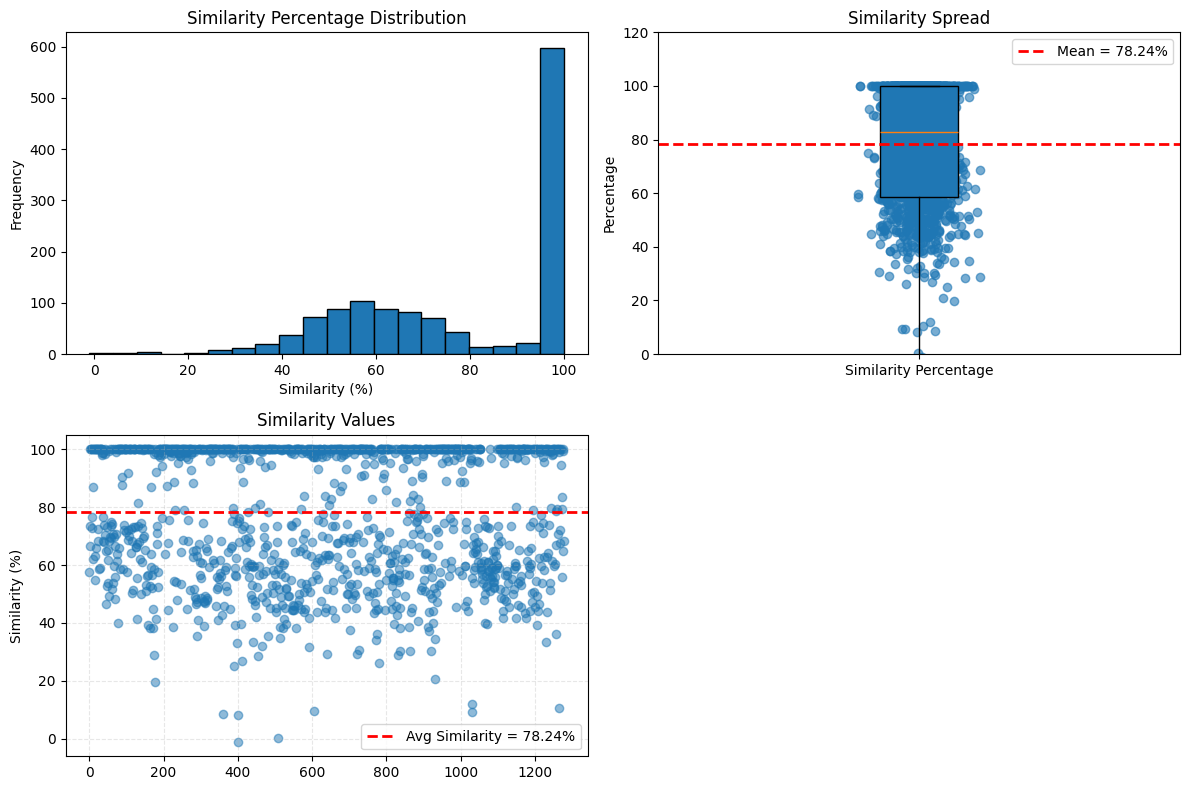

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

data = similarity['similarity_pct'].values
mean_val = data.mean()

# a. Histogram
axes[0, 0].hist(data, bins=20, edgecolor='black')
axes[0, 0].set_title('Similarity Percentage Distribution')
axes[0, 0].set_xlabel('Similarity (%)')
axes[0, 0].set_ylabel('Frequency')

# b. Boxplot + Beeswarm
axes[0, 1].boxplot(
    data,
    labels=['Similarity Percentage'],
    patch_artist=True,
    showfliers=False
)

x_jitter = np.random.normal(
    loc=1,
    scale=0.04,
    size=len(data)
)

axes[0, 1].scatter(
    x_jitter,
    data,
    alpha=0.6
)

axes[0, 1].axhline(
    mean_val,
    linestyle='--',
    color='red',
    linewidth=2,
    label=f'Mean = {mean_val:.2f}%'
)

axes[0, 1].set_ylim(0, 120)
axes[0, 1].set_ylabel('Percentage')
axes[0, 1].set_title('Similarity Spread')
axes[0, 1].legend()

# c. Scatter plot (values over index)
axes[1, 0].scatter(
    range(len(data)),
    data,
    alpha=0.5
)

axes[1, 0].axhline(
    mean_val,
    linestyle='--',
    color='red',
    linewidth=2,
    label=f'Avg Similarity = {mean_val:.2f}%'
)

axes[1, 0].set_ylabel('Similarity (%)')
axes[1, 0].set_title('Similarity Values')
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle='--', alpha=0.3)

# d. (opsional) kosongkan subplot terakhir
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1279 entries, 0 to 1278
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   业务类型            1279 non-null   object 
 1   会话ID            1279 non-null   object 
 2   工单ID            1279 non-null   object 
 3   会话开始时间          1279 non-null   object 
 4   会话结束时间          1279 non-null   object 
 5   客服输入内容          1271 non-null   object 
 6   AI总结内容          1279 non-null   object 
 7   客服描述内容          1271 non-null   object 
 8   AI描述内容          1279 non-null   object 
 9   描述内筒是否相同        1279 non-null   object 
 10  客服描述-工单问题类型     1271 non-null   object 
 11  AI-工单问题类型       1279 non-null   object 
 12  工单类型是否相同        1279 non-null   object 
 13  AI-总结时间         1279 non-null   object 
 14  工单提报时间          1271 non-null   object 
 15  处理人             1279 non-null   object 
 16  similarity_pct  1279 non-null   float64
dtypes: float64(1), object(16)
memory 

In [ ]:
similarity_text = df.iloc[:,[0,2,7,8,16]]
similarity_text[(similarity_text['业务类型'] == 'ASI_LOAN') & (similarity_text['similarity_pct'] < 50)].sort_values(by='similarity_pct', ascending=False)

,业务类型,工单ID,客服描述内容,AI描述内容,similarity_pct
284,ASI_LOAN,22868537,\nKendala : Cust mengajukan keringanan/diskon...,1. Masalah【1】\n Pengguna menanyakan keaslian...,49.13
1116,ASI_LOAN,22867585,Cust info : Permintaan keringanan diskon denda...,1. Nomor Telepon Pengguna\n 081553854215\n\n...,48.43
358,ASI_LOAN,22865617 22865587,QUE ANTRIAN CHAT // CUST info:user emlakukan p...,1. Nomor Telepon Pengguna\n 083874761375\n\n...,42.60
592,ASI_LOAN,22867856 22867872,Cust suddah bayar masih ditagih// agent bantu ...,1. Nomor Telepon Pengguna\n 081228133291\n\n...,41.73
1231,ASI_LOAN,22866656,No.Pesanan: -\nKendala:cust infokan terkait ke...,1. Email\n cs.pinjaman@akulaku.com\n\n2. Mas...,33.45
931,ASI_LOAN,22869682 22869694,Cust kendala Paylater // agen transfer AFI\n,1. Masalah【1】\n Pengguna mengalami kendala t...,20.75
1264,ASI_LOAN,22863153,NaN,1. Masalah【1】\n Kemarin sudah mengajukan ker...,10.49
604,ASI_LOAN,22872111,NaN,1. Nomor Telepon Pengguna\n 083873635114\n\n...,9.43


: 